In [60]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

from google.colab import drive
drive.mount("/content/drive")

#set plotting style
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#loading dataset

In [62]:
#load dataset
file_path = "/content/drive/MyDrive/Colab Notebooks/Bitcoin_Project/Processed_Dataset.csv"
df = pd.read_csv(file_path)
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}\n")

Dataset shape: (2928, 19)
Columns: ['timestamp', 'close', 'volume', 'log_volume', 'returns_scaled', 'buy_pressure', 'next_day_return', 'pressure_bin', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'ema_12', 'ema_26', 'ema_gap', 'rsi', 'volatility_7d', 'daily_momentum', 'target']



In [63]:
df.head()

,timestamp,close,volume,log_volume,returns_scaled,buy_pressure,next_day_return,pressure_bin,day_sin,day_cos,month_sin,month_cos,ema_12,ema_26,ema_gap,rsi,volatility_7d,daily_momentum,target
0,2018-03-09 00:00:00+00:00,9227.00,64112.291407,20.156016,-0.181754,0.486122,-1.719880,Bearish (<49%),-0.433884,-0.900969,0.866025,0.5,10256.918248,10284.560978,-0.100412,40.478996,1.495415,-0.004815,-1.719880
1,2018-03-10 00:00:00+00:00,8770.22,37180.012857,19.648009,-1.719880,0.474444,2.979629,Bearish (<49%),-0.974928,-0.222521,0.866025,0.5,10028.195440,10172.387572,-0.125444,37.319008,1.165226,-0.049505,2.979629
2,2018-03-11 00:00:00+00:00,9533.57,44325.973386,19.815665,2.979629,0.477152,-1.468156,Bearish (<49%),-0.781831,0.623490,0.866025,0.5,9952.099219,10125.067752,-0.042054,45.040479,1.966092,0.087039,-1.468156
3,2018-03-12 00:00:00+00:00,9131.34,42230.777930,19.795820,-1.468156,0.458663,0.054289,Bearish (<49%),0.000000,1.000000,0.866025,0.5,9825.828570,10051.458289,-0.070680,42.097698,1.950749,-0.042191,0.054289
4,2018-03-13 00:00:00+00:00,9150.00,40191.409358,19.721836,0.054289,0.494047,-3.702306,Neutral,0.781831,0.623490,0.866025,0.5,9721.854944,9984.683601,-0.058822,42.286088,1.914004,0.002044,-3.702306


#Data preparation ⁉

Why the timestamp Column is Excluded from FeaturesWhile the timestamp is essential for organizing our data, it is excluded from the feature set ($X$) provided to the XGBoost model for the following reasons:1. Prevention of OverfittingA raw timestamp is a unique identifier for every row. If included, the model might "memorize" specific events tied to a single point in time rather than learning the underlying patterns that cause price movements. This leads to overfitting, where the model performs perfectly on past data but fails to generalize to future data.2. Feature Redundancy (Signal vs. Noise)We have already performed Feature Engineering to extract the "meaningful" parts of the timestamp into new columns:hour_sin / hour_cos: Captures intraday cycles.day_sin / day_cos: Captures weekly seasonality (weekends vs. weekdays).is_quarter_end: Captures broader financial cycles.Since these engineered features represent the actual logic of how time affects the market, the raw timestamp becomes "noise" that adds no additional value.3. Mathematical Constraints of Tree-Based ModelsXGBoost and other tree-based algorithms split data based on numerical thresholds. Raw timestamps (often represented as massive integers or strings) do not follow a repeating numerical pattern. By using cyclical features (Sine/Cosine), we provide the model with bounded, repeating values that are much easier for the algorithm to use for mathematical splits.4. Maintaining Chronological OrderExcluding the column from the Features does not mean we ignore the Time. We still use the timestamp to:Sort the data chronologically before splitting to ensure no data leakage.Align the target so the model learns to predict the future based on the past.

In [64]:
#identify label or target column
#Handle timestampl
print("=="*20)
print("Handling Timestamp")
print("=="*20)
features = [
    'buy_pressure',
    'log_volume',
    'day_sin', 'day_cos',
    'month_sin', 'month_cos',
    'ema_gap',
    'rsi',
    'volatility_7d',
    'daily_momentum'
]
x = df[features]
y = df['target']
print(f"Number of features: {len(features)}" )

print("=="*20)
print("Checking missing values")
print("=="*20)
if x.isnull().sum().sum()>0:
  print(f"Warning {x.isnull().sum().sum()}missing values detected")
  x = x.fillna(method='ffill').fillna(method='bfill')
  print("Missing values Filled using forward/backward fill")
else :
  print("No Missing Values on Features")

if y.isnull().sum()>0:
  print(f"Warning: {y.isnull().sum()}missng target values detected")
  y = y.fillna(method='ffil').fillna(method='bfill')
  print("Missing target values filled ")
else:
  print("No missing values on Target")

Handling Timestamp
Number of features: 10
Checking missing values
No Missing Values on Features
No missing values on Target


#Time Series Cross-Validaton Setup
why using time series split instead of random 80/20
-Time series data has temporal dependencies
-TimeSeries Split respects choronological order
-Radom Splitting would leak future information into training
-Each fold past dat to predict future data
###K-Fold configuration
-n_splits : Number of folda (typically 5-10 times series )
- Each split progressively increases training set size
- Test set is always after training set in time

hat this code does:

This code sets up a Progressive Training Window (also known as Forward Chaining) to test our model. In financial data like Bitcoin, we cannot use standard random shuffling because it would let the model "cheat" by looking at the future to predict the past.
The 5-Fold Logic:

    Fold 1: Trains on a small starting piece of data and tests on the next immediate chunk.

    Expanding Window: In each following fold, the previous "Test" data is added to the "Train" set.

    Moving Forward: The model always moves forward in time, ensuring that we only ever use past data to predict future results.

Time series cross-validation configured with 5 splits
  -Methode: Progressive training widow
  -Each fold usese past data to predict future
  -No data leakage from future to past

Cross-validation strategy visaulization Done
Cross-validation strategy visaulization Done
Cross-validation strategy visaulization Done
Cross-validation strategy visaulization Done
Cross-validation strategy visaulization Done


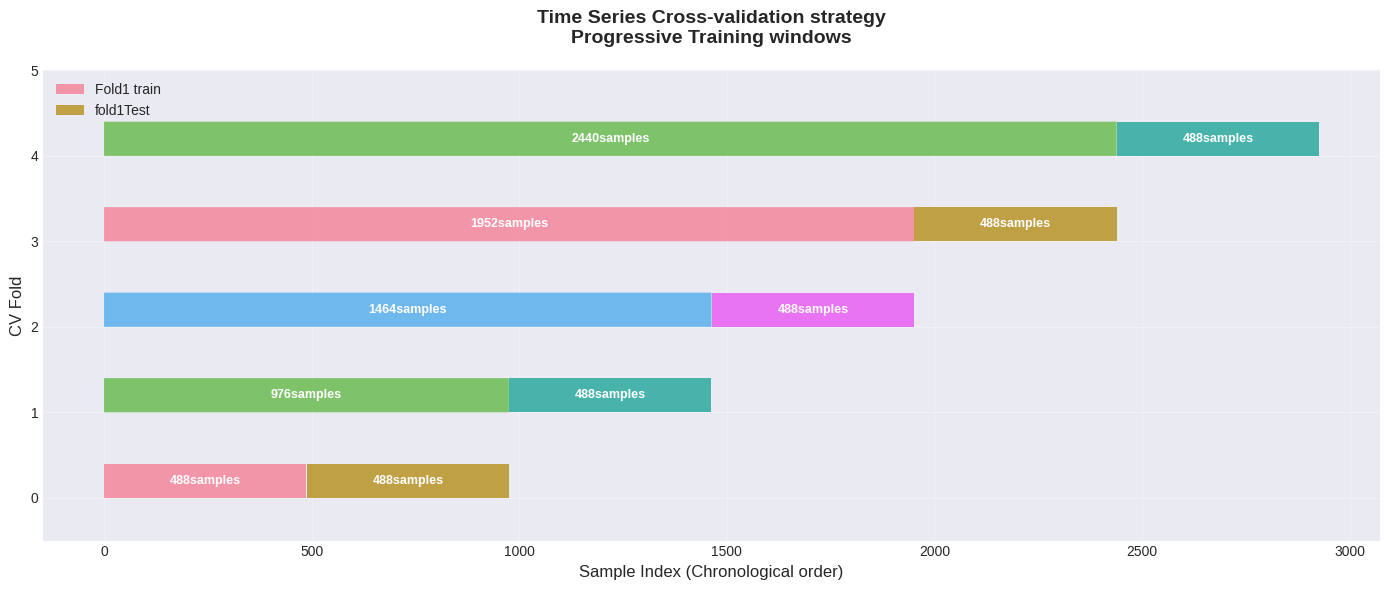

In [65]:
n_splits = 5
tscv = TimeSeriesSplit(n_splits = n_splits)
print(f"Time series cross-validation configured with {n_splits} splits")
print(f"  -Methode: Progressive training widow")
print(f"  -Each fold usese past data to predict future")
print(f"  -No data leakage from future to past\n")
#visualize splits
fig,ax = plt.subplots(figsize=(14,6))
for i,(train_idx,test_idx) in enumerate(tscv.split(x)):
  #create array for visualization
  indices = np.arange(len(x))
  train_mask = np.zeros(len(x))
  test_mask = np.zeros(len(x))
  train_mask[train_idx]=1
  test_mask[test_idx]=1
  ax.fill_between(indices,i,i+0.4,where=train_mask,alpha=0.7,label=f"Fold{i+1} train" if i == 0 else '')
  ax.fill_between(indices,i,i+0.4,where=test_mask,alpha=0.9,label=f"fold{i+1}Test" if i == 0 else '')
  ax.text(train_idx[len(train_idx)//2],i+0.2,f"{len(train_idx)}samples",ha ='center',va='center',fontsize=9,color='white',weight='bold')
  ax.text(test_idx[len(test_idx)//2],i+0.2,f'{len(test_idx)}samples',ha ='center',va='center',fontsize=9,color='white',weight='bold')
  ax.set_ylim(-0.5,n_splits)
  ax.set_xlabel("Sample Index (Chronological order)",fontsize=12)
  ax.set_ylabel('CV Fold',fontsize=12)
  ax.set_title("Time Series Cross-validation strategy\nProgressive Training windows",
               fontsize=14,weight='bold',pad =20)
  ax.legend(loc='upper left')
  ax.grid(True,alpha=0.3)
  plt.tight_layout()
  print("Cross-validation strategy visaulization Done")

In [66]:
#XGBoost hyperparameters
params = {
    'n_estimators':2000,
    'max_depth':6,
    'learning_rate':0.01,
    'subsample':0.8,
    'colsample_bytree':0.8,
    'reg_alpha':0.1,
    'reg_lambda':1.0,
    'random_state':42,
    'objective':'reg:squarederror',
    'tree_method':'hist',
    'eval_metric':'rmse',
    'early_stopping_rounds':50
}
print("XGBoost Configuration:")
for key,value in params.items():
  print(f" {key:20s}:{value}")

cv_results = {
    'fold':[],
    'train_rmse':[],
    'test_rmse':[],
    'train_mae':[],
    'test_mae':[],
    'train_r2':[],
    "test_r2":[],
    'feature_importance':[],
    'predictions':[],
    'actuals':[],
    'test_indices':[]
}

for fold,(train_idx,test_idx) in enumerate(tscv.split(x),1):
  print(f"{'='*60}")
  print(f"{fold}/{n_splits}")
  print(f"{'='*60}")
  #split data
  x_train,x_test = x.iloc[train_idx],x.iloc[test_idx]
  y_train,y_test = y.iloc[train_idx],y.iloc[test_idx]
  print(f"Training samples: {len(x_train):,}")
  print(f"Testing samples:  {len(x_test):,}")
  model = xgb.XGBRegressor(**params)
  #Train and with Early Stopping to prevent overfitting
  eval_set = [(x_train,y_train),(x_test,y_test)]
  model.fit(x_train,y_train,eval_set=eval_set,verbose=False)
  y_train_pred = model.predict(x_train)
  y_test_pred = model.predict(x_test)
  train_rmse = np.sqrt(mean_squared_error(y_train,y_train_pred))
  test_rmse = np.sqrt(mean_squared_error(y_test,y_test_pred))
  train_mae =mean_absolute_error(y_train,y_train_pred)
  test_mae = mean_absolute_error(y_test,y_test_pred)
  train_r2 = r2_score(y_train,y_train_pred)
  test_r2 = r2_score(y_test,y_test_pred)
  print(f"\nResults:")
  print(f"Train RMSE: {train_rmse:.6f}")
  print(f"Test RMSE: {test_rmse:.6f}")
  print(f"Train MAE: {train_mae:.6f}")
  print(f"Test MAE: {test_mae:.6f}")
  print(f"Train R: {train_r2:.6f}")
  print(f"Test R: {test_r2:.6f}")
  #Store Results
  cv_results['fold'].append(fold)
  cv_results['train_rmse'].append(train_rmse)
  cv_results['test_rmse'].append(test_rmse)
  cv_results['train_mae'].append(train_mae)
  cv_results['test_mae'].append(test_mae)
  cv_results['train_r2'].append(train_r2)
  cv_results['test_r2'].append(test_r2)
  cv_results['feature_importance'].append(model.feature_importances_)
  cv_results['predictions'].append(y_test_pred)
  cv_results['actuals'].append(y_test.values)
  cv_results['test_indices'].append(test_idx)
  print()

XGBoost Configuration:
 n_estimators        :2000
 max_depth           :6
 learning_rate       :0.01
 subsample           :0.8
 colsample_bytree    :0.8
 reg_alpha           :0.1
 reg_lambda          :1.0
 random_state        :42
 objective           :reg:squarederror
 tree_method         :hist
 eval_metric         :rmse
 early_stopping_rounds:50
1/5
Training samples: 488
Testing samples:  488

Results:
Train RMSE: 1.162177
Test RMSE: 1.205570
Train MAE: 0.796836
Test MAE: 0.794820
Train R: 0.146176
Test R: 0.006653

2/5
Training samples: 976
Testing samples:  488

Results:
Train RMSE: 1.221604
Test RMSE: 1.413688
Train MAE: 0.819798
Test MAE: 1.040940
Train R: 0.019872
Test R: -0.000512

3/5
Training samples: 1,464
Testing samples:  488

Results:
Train RMSE: 1.220814
Test RMSE: 1.025782
Train MAE: 0.854392
Test MAE: 0.701450
Train R: 0.113562
Test R: -0.000008

4/5
Training samples: 1,952
Testing samples:  488

Results:
Train RMSE: 1.165080
Test RMSE: 0.882978
Train MAE: 0.809216
Test

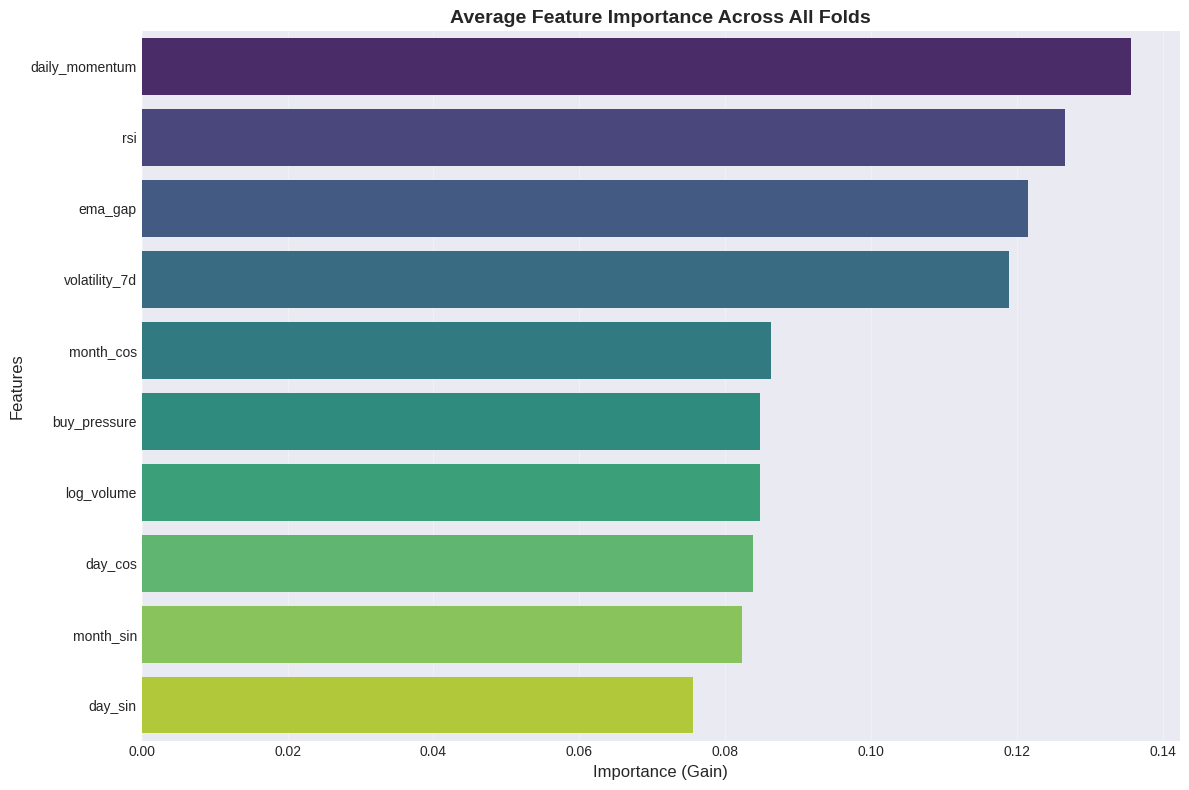

In [67]:
#Plot Features based on importance
# Average the importances across all 5 folds
avg_importance = np.mean(cv_results['feature_importance'], axis=0)

# Match them with your feature names (Assuming 'X' is your training features)
feature_names = x.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': avg_importance
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Average Feature Importance Across All Folds', fontsize=14, weight='bold')
plt.xlabel('Importance (Gain)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [53]:
avg_train_r2 = np.mean(cv_results['train_r2'])
avg_test_r2 = np.mean(cv_results['test_r2'])
avg_train_r2,avg_test_r2

(np.float64(0.036131719575919916), np.float64(0.0015183956141049172))